In [7]:
import sys
from functools import partial
sys.path.append('../')
from math import log, comb, cos, sin
from numpy.linalg import matrix_power
from spd.OperatorSequence import *
from spd.SparsePauliDynamics import *
from spd.LightPauliDynamics import *
from pauli import *
from quantum_simulation_recipe.spin import Nearest_Neighbour_1d
from quantum_simulation_recipe.trotter import pf, expH
from qiskit.quantum_info import SparsePauliOp, random_statevector
import matplotlib.pyplot as plt

import numpy as np
from quantity import *
from qiskit import QuantumCircuit
from qiskit.circuit.library import PauliEvolutionGate
from qiskit.synthesis import LieTrotter
from qiskit.circuit import Parameter
from qiskit.quantum_info import Statevector, SparsePauliOp, DensityMatrix, partial_trace, entropy
from qiskit_aer import AerSimulator
from qiskit_aer.library import save_statevector, save_density_matrix

fig_dir, data_dir = './figs', './data'

In [21]:
qmfi.ham

SparsePauliOp(['IIXX', 'IXXI', 'XXII', 'XIIX', 'IIIY', 'IIYI', 'IYII', 'YIII'],
              coeffs=[1. +0.j, 1. +0.j, 1. +0.j, 1. +0.j, 0.9+0.j, 0.9+0.j, 0.9+0.j, 0.9+0.j])

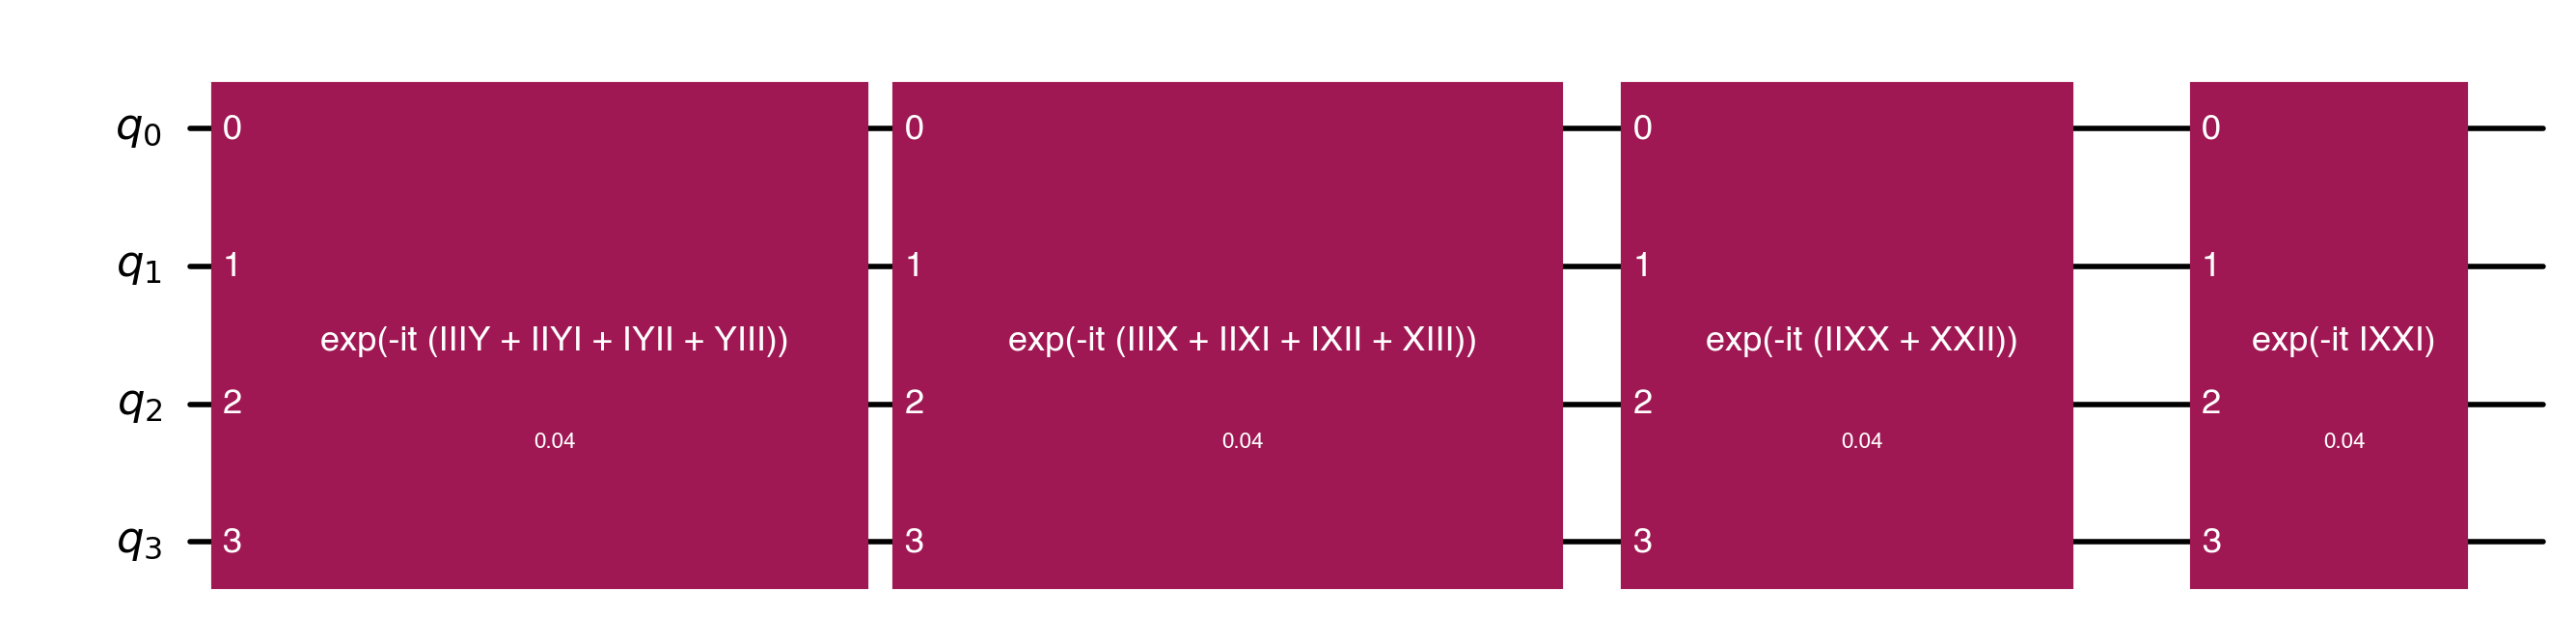

In [ ]:
t = 2
r = 50
dt = t/r

n = 4
Jx, hx, hy = 1.0, 0.8, 0.9
# Jx, hx, hy = 1.0, 0.0, 0.9
qmfi = Nearest_Neighbour_1d(n, Jx=Jx, hx=hx, hy=hy, pbc=False)
xx_even = SparsePauliOp.from_sparse_list([*qmfi.xx_tuples[::2]], num_qubits=n).simplify()
xx_odd = SparsePauliOp.from_sparse_list([*qmfi.xx_tuples[1::2]], num_qubits=n).simplify()
x_terms = SparsePauliOp.from_sparse_list([*qmfi.x_tuples], num_qubits=n).simplify()
H_list = [x_terms, qmfi.y_terms, xx_even, xx_odd] # [xx_even, x_terms, qimf.y_terms,xx_odd]

pf1_xx_e = PauliEvolutionGate(xx_even, dt, synthesis=LieTrotter())
pf1_xx_o = PauliEvolutionGate(xx_odd, dt, synthesis=LieTrotter())
pf1_x = PauliEvolutionGate(x_terms, dt, synthesis=LieTrotter())
pf1_y = PauliEvolutionGate(qmfi.y_terms, dt, synthesis=LieTrotter())

# We create an empty circuit
circuit_pf1_eo = QuantumCircuit(qmfi.n)
circuit_pf1_eo.append(pf1_y, range(qmfi.n))
circuit_pf1_eo.append(pf1_x, range(qmfi.n))
circuit_pf1_eo.append(pf1_xx_e, range(qmfi.n))
circuit_pf1_eo.append(pf1_xx_o, range(qmfi.n))

circuit_pf1_eo_0 = circuit_pf1_eo.decompose(reps=0)
circuit_pf1_eo_0.draw("mpl")

In [ ]:

def trotter_step_circuit(n, J_x, h_x, h_y, dt, periodic=True):
    """
    Create a single Trotter step circuit for e^(-i H dt)
    Using first-order Trotter: e^(-i H dt) ≈ e^(-i H_XX dt) e^(-i H_X dt) e^(-i H_Y dt)
    """
    qc = QuantumCircuit(n)
    
    # Apply XX interaction terms: e^(-i J_x X_j X_{j+1} dt)
    for j in range(n):
        if j < n-1:
            # RZZ gate implements e^(-i θ/2 Z⊗Z)
            # We need XX, so use H gates to convert: HZH = X
            qc.h([j, j+1])
            qc.rzz(-2 * J_x * dt, j, j+1)
            qc.h([j, j+1])
        elif periodic:
            qc.h([n-1, 0])
            qc.rzz(-2 * J_x * dt, n-1, 0)
            qc.h([n-1, 0])
    
    # Apply X field terms: e^(-i h_x X_j dt)
    for j in range(n):
        qc.rx(2 * h_x * dt, j)
    
    # Apply Y field terms: e^(-i h_y Y_j dt)
    for j in range(n):
        qc.ry(2 * h_y * dt, j)
    
    return qc

def simulate_with_mps(circuit, initial_state=None, max_bond_dimension=None):
    """
    Simulate the circuit using MPS (Matrix Product State) method
    Returns statevector and simulation metadata including truncation error
    """
    # Configure the MPS simulator
    backend_options = {
        "method": "matrix_product_state",
        "matrix_product_state_max_bond_dimension": max_bond_dimension if max_bond_dimension else 64,
        "matrix_product_state_truncation_threshold": 1e-10,
        "mps_log_data": True  # Enable logging of MPS data
    }
    
    # Create simulator
    simulator = AerSimulator(method='matrix_product_state')
    
    # Add measurement or state vector save
    circuit_copy = circuit.copy()
    circuit_copy.save_statevector()
    
    # Run simulation
    job = simulator.run(circuit_copy, shots=1, **backend_options)
    result = job.result()
    
    # Get the final state
    statevector = result.get_statevector()
    
    # Extract MPS metadata if available
    mps_data = {}
    try:
        # Get the simulation metadata
        if hasattr(result, 'results') and len(result.results) > 0:
            metadata = result.results[0].metadata
            if 'mps_bond_dimensions' in metadata:
                mps_data['bond_dimensions'] = metadata['mps_bond_dimensions']
            if 'mps_truncation_error' in metadata:
                mps_data['truncation_error'] = metadata['mps_truncation_error']
            if 'mps_discarded_value' in metadata:
                mps_data['discarded_value'] = metadata['mps_discarded_value']
    except:
        pass
    
    return statevector, result, mps_data


def time_evolution_qmfi_mps(n, J_x, h_x, h_y, total_time, num_steps, 
                            max_bond_dim=64, periodic=True):
    """
    Perform time evolution of QMFI Hamiltonian using Trotter and MPS
    """
    dt = total_time / num_steps
    
    # Create the full circuit with multiple Trotter steps
    qc = QuantumCircuit(n)
    
    # Initial state is |00...00⟩ (already the default)
    
    # Apply Trotter steps
    for step in range(num_steps):
        trotter_circuit = trotter_step_circuit(n, J_x, h_x, h_y, dt, periodic)
        qc.compose(trotter_circuit, inplace=True)
    
    # Simulate with MPS
    final_state, result, mps_data = simulate_with_mps(qc, max_bond_dimension=max_bond_dim)
    
    return qc, final_state, result, mps_data



In [ ]:

# Main execution
# if __name__ == "__main__":

# Parameters from the paper
n = 10  # number of sites
Jx = 1.0
hx = 0.0
hy = 0.9

# Time evolution parameters
total_time = 2.0  # Total evolution time
num_trotter_steps = 50  # Number of Trotter steps
max_bond_dimensions = [16, 32, 64, 128]  # Different bond dimensions to test

print(f"QMFI Hamiltonian Parameters:")
print(f"n = {n}, J_x = {Jx}, h_x = {hx}, h_y = {hy}")
print(f"Total time = {total_time}, Trotter steps = {num_trotter_steps}")
print("-" * 50)

# Build Hamiltonian (for reference/checking)
# H = build_qmfi_hamiltonian(n, J_x, h_x, h_y, periodic=True)
H = Nearest_Neighbour_1d(n, hx=hx, hy=hy, Jx=Jx, pbc=False).ham
print(f"Hamiltonian has {len(H)} terms")

# Time evolution study with entanglement entropy and MPS error
print("\n" + "="*50)
print("Time Evolution with Entanglement Entropy and MPS Error Analysis")
print("="*50)

time_points = np.linspace(0, 3.0, 31)

# Storage for different bond dimensions
results = {}
for max_bond_dim in max_bond_dimensions:
    results[max_bond_dim] = {
        'entropy': [],
        'mag_x': [],
        'mag_y': [],
        'mag_z': [],
        'fidelity': [],
        'mps_error': []
    }

# Also compute exact evolution for small times (for comparison)
exact_entropy = []
exact_mag_x = []
exact_mag_y = []
exact_mag_z = []

print("\nComputing evolution...")
for i, t in enumerate(time_points):
    print(f"\nTime t = {t:.2f}")
    
    if t == 0:
        # Initial state |00...00⟩
        initial_state = Statevector.from_label('0' * n)
        
        # Compute entropy of first 2 qubits
        entropy_val = compute_entanglement_entropy(initial_state, [0, 1], n)
        obs = compute_observables(initial_state, n)
        
        # Same for all bond dimensions at t=0
        for max_bond_dim in max_bond_dimensions:
            results[max_bond_dim]['entropy'].append(entropy_val)
            results[max_bond_dim]['mag_x'].append(obs['mag_x'])
            results[max_bond_dim]['mag_y'].append(obs['mag_y'])
            results[max_bond_dim]['mag_z'].append(obs['mag_z'])
            results[max_bond_dim]['fidelity'].append(1.0)
            results[max_bond_dim]['mps_error'].append(0.0)
        
        exact_entropy.append(entropy_val)
        exact_mag_x.append(obs['mag_x'])
        exact_mag_y.append(obs['mag_y'])
        exact_mag_z.append(obs['mag_z'])
        
    else:
        # Compute exact evolution (for comparison, only for moderate system sizes)
        if n <= 12:  # Only compute exact for small systems
            exact_state = exact_evolution(n, Jx, hx, hy, t, periodic=True)
            exact_ent = compute_entanglement_entropy(exact_state, [0, 1], n)
            exact_obs = compute_observables(exact_state, n)
            exact_entropy.append(exact_ent)
            exact_mag_x.append(exact_obs['mag_x'])
            exact_mag_y.append(exact_obs['mag_y'])
            exact_mag_z.append(exact_obs['mag_z'])
            print(f"  Exact: S_12 = {exact_ent:.6f}")
        
        # Evolve with different bond dimensions
        for max_bond_dim in max_bond_dimensions:
            num_steps = max(1, int(t * 20))  # Adaptive number of steps
            _, state_t, _, mps_data = time_evolution_qmfi_mps(
                n, Jx, hx, hy, t, num_steps,
                max_bond_dim=max_bond_dim, periodic=True
            )
            
            # Compute entanglement entropy of first 2 qubits
            entropy_val = compute_entanglement_entropy(state_t, [0, 1], n)
            obs = compute_observables(state_t, n)
            
            results[max_bond_dim]['entropy'].append(entropy_val)
            results[max_bond_dim]['mag_x'].append(obs['mag_x'])
            results[max_bond_dim]['mag_y'].append(obs['mag_y'])
            results[max_bond_dim]['mag_z'].append(obs['mag_z'])
            
            # Compute fidelity with exact state if available
            if n <= 12 and t > 0:
                fidelity = compute_mps_fidelity(state_t, exact_state)
                results[max_bond_dim]['fidelity'].append(fidelity)
            else:
                results[max_bond_dim]['fidelity'].append(np.nan)
            
            # Store MPS truncation error if available
            if 'truncation_error' in mps_data:
                results[max_bond_dim]['mps_error'].append(mps_data['truncation_error'])
            else:
                results[max_bond_dim]['mps_error'].append(0.0)
            
            print(f"  χ={max_bond_dim:3d}: S_12 = {entropy_val:.6f}, "
                    f"<M_x> = {obs['mag_x']:.4f}")


QMFI Hamiltonian Parameters:
n = 10, J_x = 1.0, h_x = 0.0, h_y = 0.9
Total time = 2.0, Trotter steps = 50
--------------------------------------------------
Hamiltonian has 19 terms

Time Evolution with Entanglement Entropy and MPS Error Analysis

Computing evolution...

Time t = 0.00

Time t = 0.10
  Exact: S_12 = 0.158295
  χ= 16: S_12 = 0.160072, <M_x> = 0.1746
  χ= 32: S_12 = 0.160072, <M_x> = 0.1746
  χ= 64: S_12 = 0.160072, <M_x> = 0.1746
  χ=128: S_12 = 0.160072, <M_x> = 0.1746

Time t = 0.20
  Exact: S_12 = 0.448438
  χ= 16: S_12 = 0.459071, <M_x> = 0.3265
  χ= 32: S_12 = 0.459071, <M_x> = 0.3265
  χ= 64: S_12 = 0.459071, <M_x> = 0.3265
  χ=128: S_12 = 0.459071, <M_x> = 0.3265

Time t = 0.30
  Exact: S_12 = 0.739829
  χ= 16: S_12 = 0.766420, <M_x> = 0.4398
  χ= 32: S_12 = 0.766420, <M_x> = 0.4398
  χ= 64: S_12 = 0.766420, <M_x> = 0.4398
  χ=128: S_12 = 0.766420, <M_x> = 0.4398

Time t = 0.40
  Exact: S_12 = 0.959391
  χ= 16: S_12 = 1.006130, <M_x> = 0.5038
  χ= 32: S_12 = 1.006

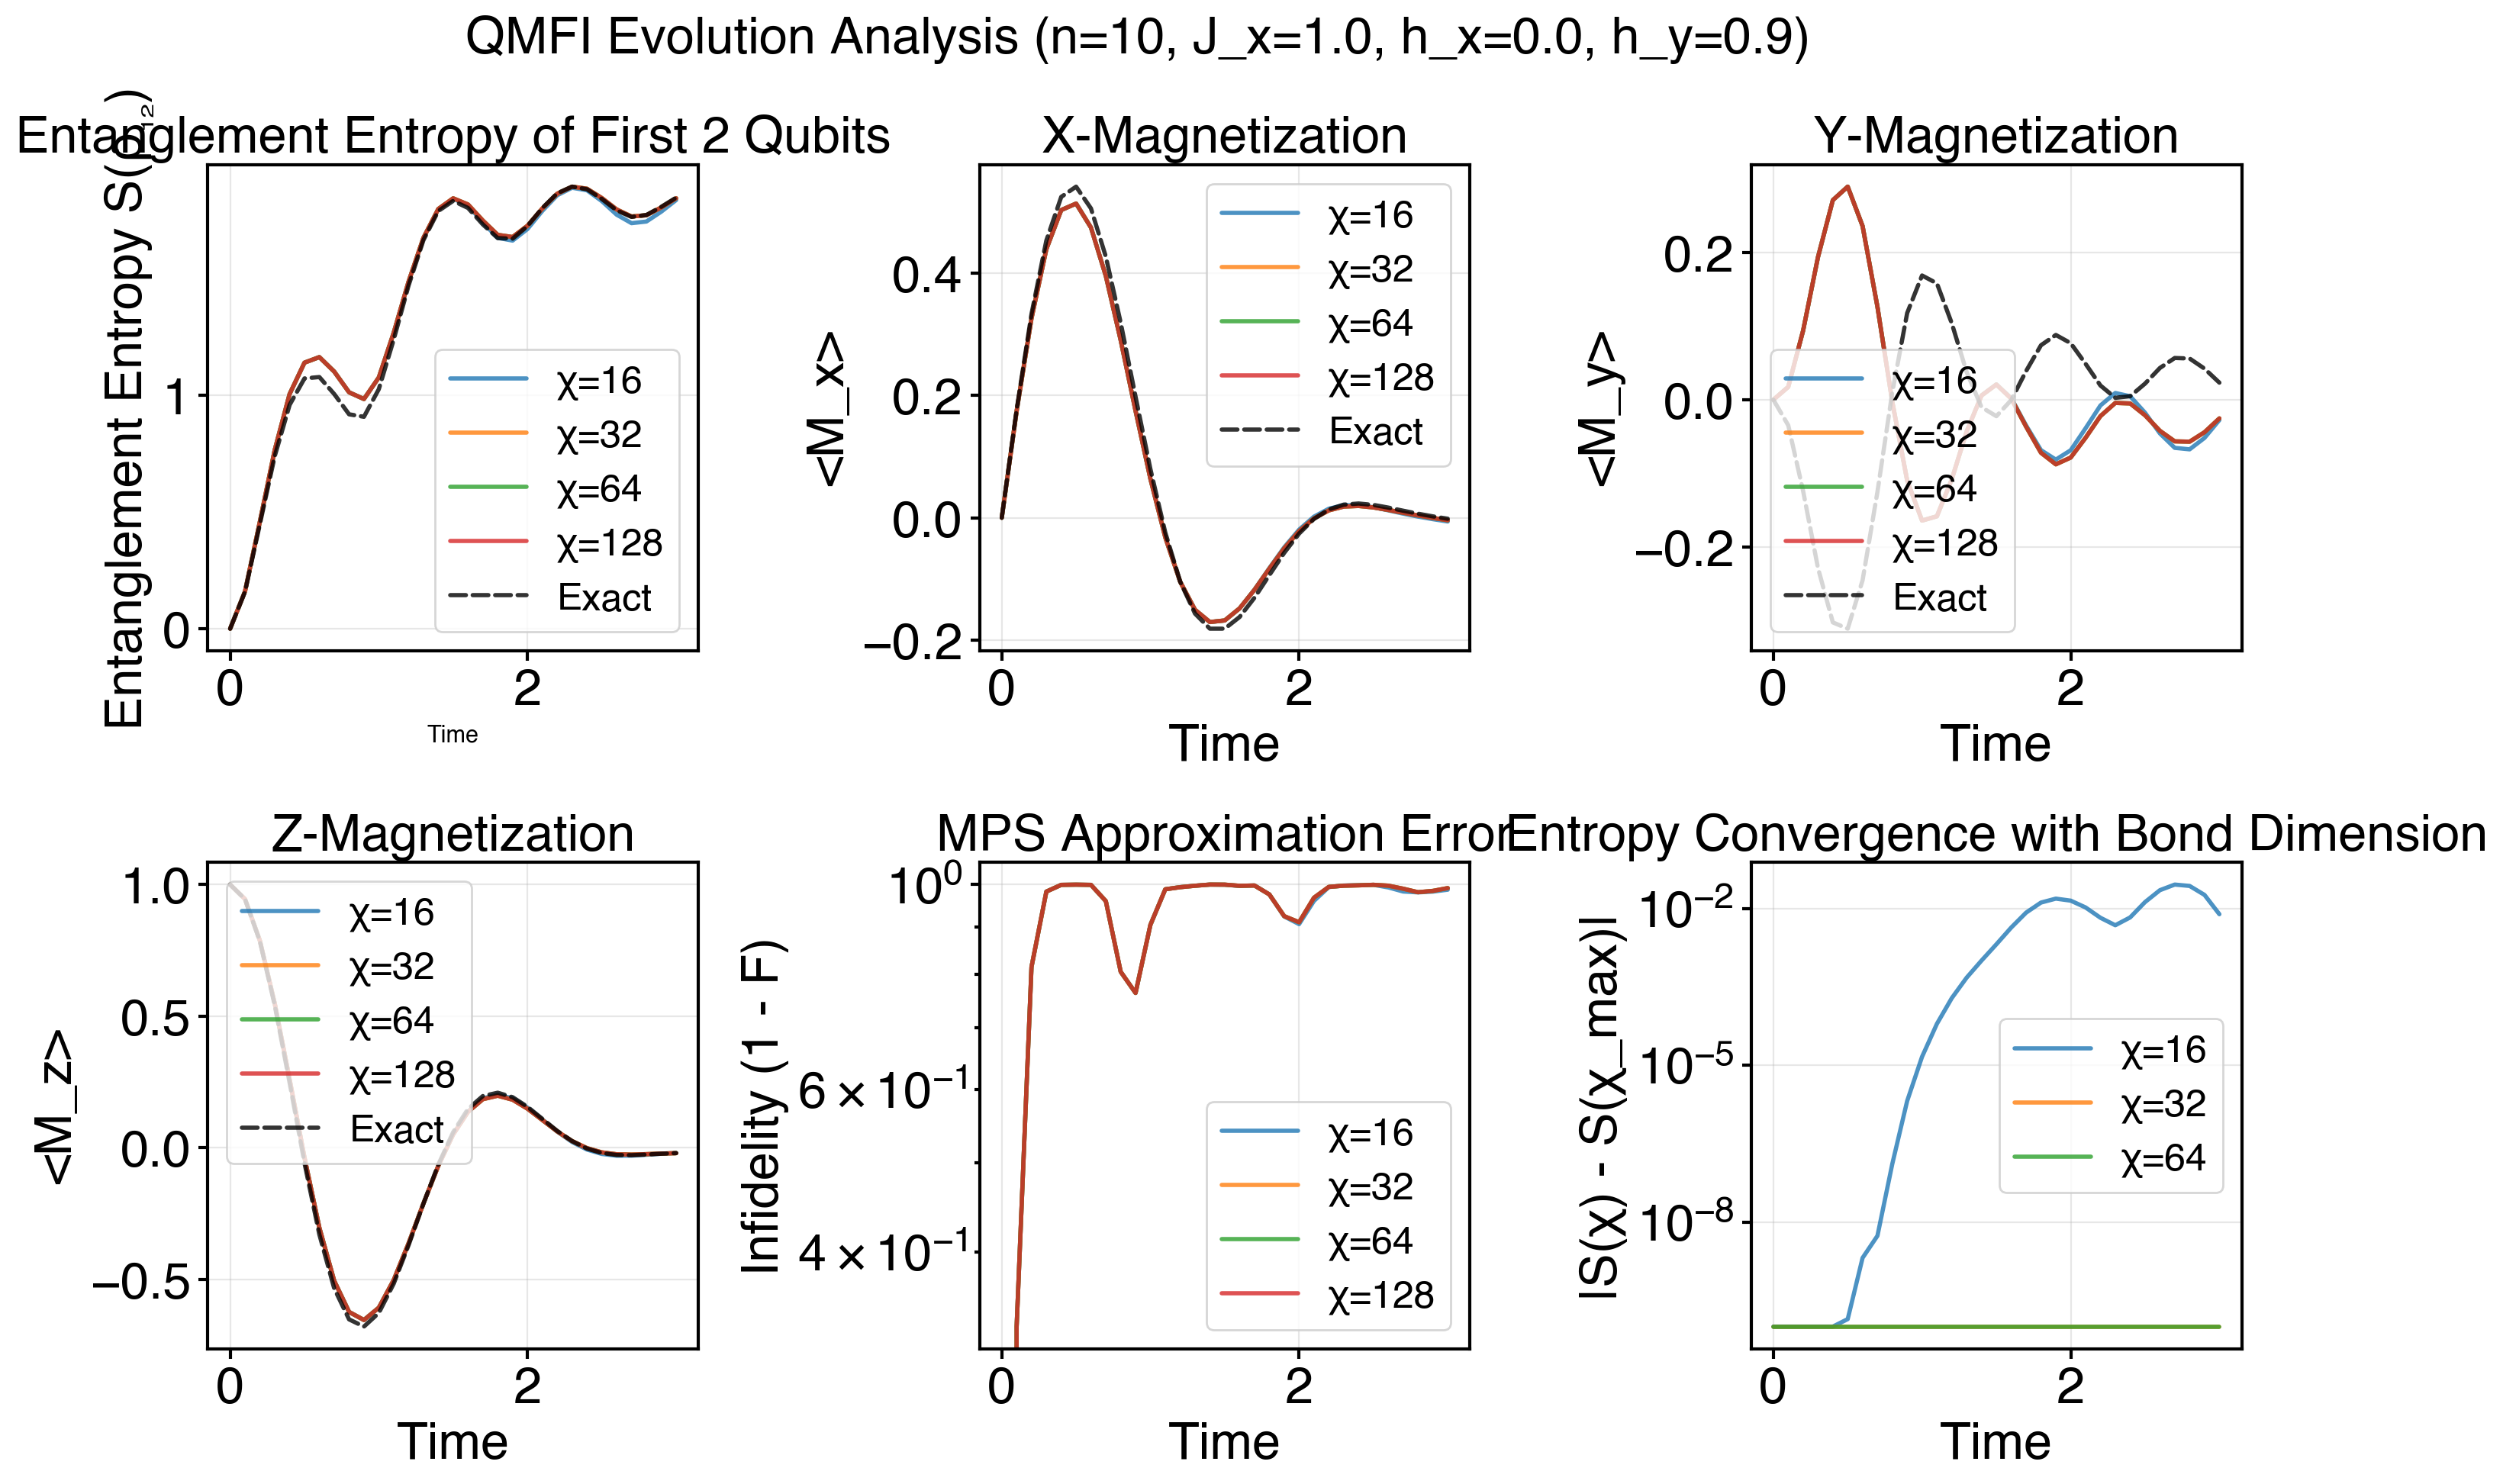


Summary Statistics at t = 3.00

Bond dimension χ = 16:
  Final S_12 = 1.837613
  Final <M_x> = -0.006126
  Final fidelity = 0.01272112

Bond dimension χ = 32:
  Final S_12 = 1.845372
  Final <M_x> = -0.004127
  Final fidelity = 0.00872905

Bond dimension χ = 64:
  Final S_12 = 1.845372
  Final <M_x> = -0.004127
  Final fidelity = 0.00872905

Bond dimension χ = 128:
  Final S_12 = 1.845372
  Final <M_x> = -0.004127
  Final fidelity = 0.00872905


In [ ]:

# Plotting
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Plot 1: Entanglement entropy of first 2 qubits
ax = axes[0, 0]
for max_bond_dim in max_bond_dimensions:
    ax.plot(time_points, results[max_bond_dim]['entropy'], 
            label=f'χ={max_bond_dim}', linewidth=2, alpha=0.8)
if n <= 12:
    ax.plot(time_points, exact_entropy, 'k--', 
            label='Exact', linewidth=2, alpha=0.8)
ax.set_xlabel('Time', fontsize=11)
ax.set_ylabel('Entanglement Entropy S(ρ₁₂)' )
ax.set_title('Entanglement Entropy of First 2 Qubits' )
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Magnetization in X
ax = axes[0, 1]
for max_bond_dim in max_bond_dimensions:
    ax.plot(time_points, results[max_bond_dim]['mag_x'], 
            label=f'χ={max_bond_dim}', linewidth=2, alpha=0.8)
if n <= 12:
    ax.plot(time_points, exact_mag_x, 'k--', 
            label='Exact', linewidth=2, alpha=0.8)
ax.set_xlabel('Time' )
ax.set_ylabel('<M_x>' )
ax.set_title('X-Magnetization' )
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 3: Magnetization in Y
ax = axes[0, 2]
for max_bond_dim in max_bond_dimensions:
    ax.plot(time_points, results[max_bond_dim]['mag_y'], 
            label=f'χ={max_bond_dim}', linewidth=2, alpha=0.8)
if n <= 12:
    ax.plot(time_points, exact_mag_y, 'k--', 
            label='Exact', linewidth=2, alpha=0.8)
ax.set_xlabel('Time' )
ax.set_ylabel('<M_y>' )
ax.set_title('Y-Magnetization' )
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 4: Magnetization in Z
ax = axes[1, 0]
for max_bond_dim in max_bond_dimensions:
    ax.plot(time_points, results[max_bond_dim]['mag_z'], 
            label=f'χ={max_bond_dim}', linewidth=2, alpha=0.8)
if n <= 12:
    ax.plot(time_points, exact_mag_z, 'k--', 
            label='Exact', linewidth=2, alpha=0.8)
ax.set_xlabel('Time' )
ax.set_ylabel('<M_z>' )
ax.set_title('Z-Magnetization' )
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 5: Fidelity with exact state (if available)
ax = axes[1, 1]
if n <= 12:
    for max_bond_dim in max_bond_dimensions:
        fidelities = [f for f in results[max_bond_dim]['fidelity'] if not np.isnan(f)]
        time_fid = [t for t, f in zip(time_points, results[max_bond_dim]['fidelity']) if not np.isnan(f)]
        if len(fidelities) > 0:
            ax.semilogy(time_fid, 1 - np.array(fidelities), 
                        label=f'χ={max_bond_dim}', linewidth=2, alpha=0.8)
    ax.set_xlabel('Time' )
    ax.set_ylabel('Infidelity (1 - F)' )
    ax.set_title('MPS Approximation Error' )
    ax.legend()
    ax.grid(True, alpha=0.3)
else:
    ax.text(0.5, 0.5, 'Exact calculation\nnot available\nfor n > 12', 
            ha='center', va='center', transform=ax.transAxes )
    ax.set_title('MPS Approximation Error' )

# Plot 6: Entropy difference from largest bond dimension
ax = axes[1, 2]
max_chi_entropy = results[max(max_bond_dimensions)]['entropy']
for max_bond_dim in max_bond_dimensions[:-1]:  # All except the largest
    entropy_diff = np.abs(np.array(results[max_bond_dim]['entropy']) - np.array(max_chi_entropy))
    ax.semilogy(time_points, entropy_diff + 1e-10, 
                label=f'χ={max_bond_dim}', linewidth=2, alpha=0.8)
ax.set_xlabel('Time' )
ax.set_ylabel('|S(χ) - S(χ_max)|' )
ax.set_title('Entropy Convergence with Bond Dimension' )
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle(f'QMFI Evolution Analysis (n={n}, J_x={J_x}, h_x={h_x}, h_y={h_y})' 
                )
plt.tight_layout()
plt.show()
fig.savefig(f"{fig_dir}/qmfi_mps_n{n}_Jx{J_x}_hx{h_x}_hy{h_y}.pdf")

# Print summary statistics
print("\n" + "="*50)
print("Summary Statistics at t = {:.2f}".format(time_points[-1]))
print("="*50)

for max_bond_dim in max_bond_dimensions:
    final_entropy = results[max_bond_dim]['entropy'][-1]
    final_mag_x = results[max_bond_dim]['mag_x'][-1]
    print(f"\nBond dimension χ = {max_bond_dim}:")
    print(f"  Final S_12 = {final_entropy:.6f}")
    print(f"  Final <M_x> = {final_mag_x:.6f}")
    if n <= 12 and not np.isnan(results[max_bond_dim]['fidelity'][-1]):
        print(f"  Final fidelity = {results[max_bond_dim]['fidelity'][-1]:.8f}")

In [16]:
len(state_t.data)

1024